In [30]:
!pip install numpy pandas scikit-learn tensorflow gensim


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gensim.downloader as api

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from gensim.models import Word2Vec, FastText

np.random.seed(42)
tf.random.set_seed(42)

In [32]:
texts = [
    "The phone camera is very clear",
    "The laptop works fast and smooth",
    "The headphones sound amazing",
    "The delivery was quick and safe",
    "The product quality is excellent",
    "The smartwatch battery lasts long",

    "The phone camera is blurry",
    "The laptop is very slow",
    "The headphones stopped working",
    "The delivery was late and careless",
    "The product quality is poor",
    "The smartwatch battery drains fast",

    "The phone was delivered yesterday",
    "The laptop has a black keyboard",
    "The headphones are kept in a box",
    "The delivery person called me",
    "The product has a user manual",
    "The smartwatch has a round screen",

    "The phone is okay",
    "The laptop is average",
    "The headphones are neither good nor bad",
    "The delivery was normal",
    "The product is fine",
    "The smartwatch is usable but not special"
]

labels = np.array([
    2,2,2,2,2,2,
    0,0,0,0,0,0,
    1,1,1,1,1,1,
    1,1,1,1,1,1
])

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X1 = vectorizer.fit_transform(texts).toarray()

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nBoW Numeric representation:")
print(X1)

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X1.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(X1, labels, epochs=100, verbose=0)

bow_model = model
bow_history = history
X_bow = X1

new_text1 = ["The phone is okay"]

new_vector1 = vectorizer.transform(new_text1).toarray()

prediction1 = model.predict(new_vector1)

print("\nProbabilities:", prediction1[0])

predicted_class = np.argmax(prediction1)

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Neutral Review")
else:
    print("Positive Review")

Vocabulary:
['amazing' 'and' 'are' 'average' 'bad' 'battery' 'black' 'blurry' 'box'
 'but' 'called' 'camera' 'careless' 'clear' 'delivered' 'delivery'
 'drains' 'excellent' 'fast' 'fine' 'good' 'has' 'headphones' 'in' 'is'
 'kept' 'keyboard' 'laptop' 'lasts' 'late' 'long' 'manual' 'me' 'neither'
 'nor' 'normal' 'not' 'okay' 'person' 'phone' 'poor' 'product' 'quality'
 'quick' 'round' 'safe' 'screen' 'slow' 'smartwatch' 'smooth' 'sound'
 'special' 'stopped' 'the' 'usable' 'user' 'very' 'was' 'working' 'works'
 'yesterday']

BoW Numeric representation:
[[0 0 0 ... 0 0 0]
 [0 1 0 ... 0 1 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 32)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699 (10.54 KB)

 Trainable params: 2,699 (10.54 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Probabilities: [0.31498653 0.37260196 0.3124115 ]
Neutral Review


In [34]:
!pip install matplotlib


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


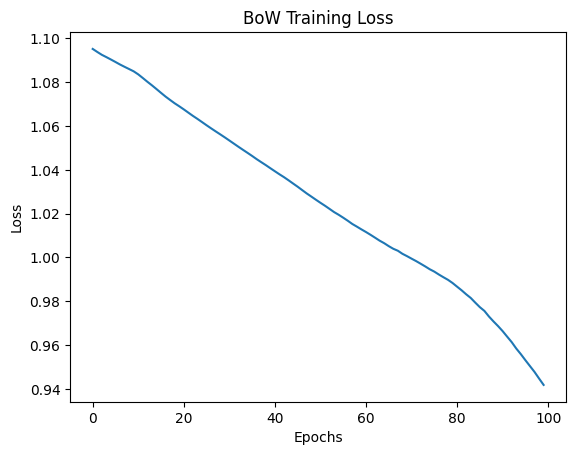

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


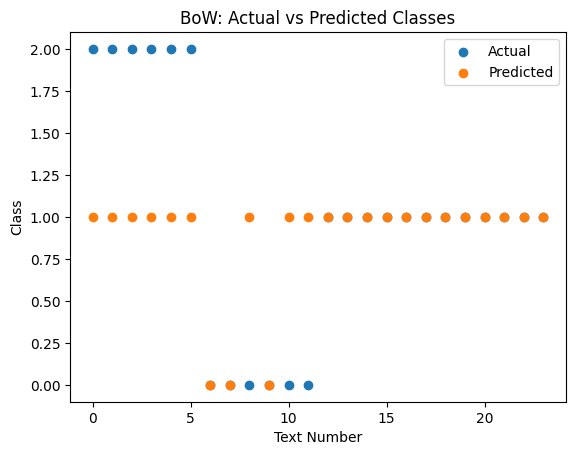

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# BoW Loss Graph
plt.plot(bow_history.history['loss'])
plt.title("BoW Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# BoW Actual vs Predicted
predicted_classes = np.argmax(bow_model.predict(X_bow), axis=1)

plt.scatter(range(len(labels)), labels, label="Actual")
plt.scatter(range(len(predicted_classes)), predicted_classes, label="Predicted")
plt.title("BoW: Actual vs Predicted Classes")
plt.xlabel("Text Number")
plt.ylabel("Class")
plt.legend()
plt.show()

#The first graph shows how the training loss decreased during epochs.  
#The second graph compares actual labels with predicted labels, so I can see how well the BoW model learned the sentiment classes.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X2 = vectorizer.fit_transform(texts).toarray()

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nTF-IDF Numeric representation:")
print(X2)

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X2.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(X2, labels, epochs=100, verbose=0)

new_text2 = ["The phone is okay"]

new_vector2 = vectorizer.transform(new_text2).toarray()

prediction2 = model.predict(new_vector2)

print("\nProbabilities:", prediction2[0])

predicted_class = np.argmax(prediction2)

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Neutral Review")
else:
    print("Positive Review")

Vocabulary:
['amazing' 'and' 'are' 'average' 'bad' 'battery' 'black' 'blurry' 'box'
 'but' 'called' 'camera' 'careless' 'clear' 'delivered' 'delivery'
 'drains' 'excellent' 'fast' 'fine' 'good' 'has' 'headphones' 'in' 'is'
 'kept' 'keyboard' 'laptop' 'lasts' 'late' 'long' 'manual' 'me' 'neither'
 'nor' 'normal' 'not' 'okay' 'person' 'phone' 'poor' 'product' 'quality'
 'quick' 'round' 'safe' 'screen' 'slow' 'smartwatch' 'smooth' 'sound'
 'special' 'stopped' 'the' 'usable' 'user' 'very' 'was' 'working' 'works'
 'yesterday']

TF-IDF Numeric representation:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.39887501 0.         ... 0.         0.49648177 0.        ]
 [0.61683602 0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.       

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 32)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699 (10.54 KB)

 Trainable params: 2,699 (10.54 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Probabilities: [0.19919316 0.6032044  0.1976025 ]
Neutral Review


In [37]:
from gensim.models import Word2Vec

tokenized_texts = [sentence.lower().split() for sentence in texts]

wordvec = Word2Vec(
    sentences=tokenized_texts,
    vector_size=20,
    window=3,
    min_count=1,
    workers=4
)

X3 = []

for sentence in tokenized_texts:

    word_vectors = []

    for word in sentence:
        word_vectors.append(wordvec.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)

    X3.append(sentence_vector)

X3 = np.array(X3)

print("Word2Vec Numeric Representation:")
print(X3)

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X3.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X3,
    labels,
    epochs=300,
    verbose=0
)

new_text3 = ["The phone is okay"]

tokenized_new = [new_text3[0].lower().split()]

new_X3 = []

for sentence in tokenized_new:

    word_vectors = []

    for word in sentence:
        word_vectors.append(wordvec.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)

    new_X3.append(sentence_vector)

new_X3 = np.array(new_X3)

prediction3 = model.predict(new_X3)

print("\nProbabilities:", prediction3[0])

predicted_class = np.argmax(prediction3)

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Neutral Review")
else:
    print("Positive Review")

Word2Vec Numeric Representation:
[[-1.59024319e-03  1.11316042e-02  2.75126603e-02  1.50999203e-02
  -3.28925089e-03  1.98036432e-05  5.23830578e-03  1.23578385e-02
  -1.07339844e-02 -4.75803250e-03 -1.36984384e-03 -5.03966911e-03
  -7.04889419e-03 -1.69565920e-02 -1.43607734e-02 -1.37100555e-03
   1.69821605e-02 -9.80598386e-03 -1.63684562e-02 -3.18796374e-03]
 [-2.35984549e-02  1.02745965e-02 -6.97030395e-04 -1.50703574e-02
   1.53432265e-02 -4.39628167e-03  1.47071155e-02  1.50656132e-02
   1.72580313e-02  2.11750157e-04  1.44512802e-02 -1.92334522e-02
  -1.64126959e-02  4.22617886e-03 -3.53411888e-03 -2.18543354e-02
  -2.30844575e-03 -2.88492441e-03 -6.91320980e-03 -1.01617770e-02]
 [ 9.33300704e-04 -9.02380049e-03 -1.22732227e-03  1.67871173e-02
  -2.54120436e-02  7.26597384e-03  3.68125252e-02  1.97922774e-02
  -1.81752518e-02  1.15722567e-02  1.79482214e-02 -8.49223137e-03
   5.91315236e-03  2.39982922e-02 -1.30675333e-02  1.60377808e-02
   8.78751278e-03  2.65526399e-02 -1.6416

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387 (5.42 KB)

 Trainable params: 1,387 (5.42 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

Probabilities: [0.13875808 0.839499   0.02174287]
Neutral Review


In [38]:
import gensim.downloader as api

glove_model = api.load("glove-wiki-gigaword-50")

tokenized_texts = [sentence.lower().split() for sentence in texts]

X4 = []

for sentence in tokenized_texts:

    word_vectors = []

    for word in sentence:
        if word in glove_model:
            word_vectors.append(glove_model[word])

    if len(word_vectors) == 0:
        sentence_vector = np.zeros(glove_model.vector_size)
    else:
        sentence_vector = np.mean(word_vectors, axis=0)

    X4.append(sentence_vector)

X4 = np.array(X4)

print("GloVe Numeric Representation:")
print(X4)

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X4.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X4,
    labels,
    epochs=300,
    verbose=0
)

new_text4 = ["The phone is okay"]

tokenized_new = [new_text4[0].lower().split()]

new_X4 = []

for sentence in tokenized_new:

    word_vectors = []

    for word in sentence:
        if word in glove_model:
            word_vectors.append(glove_model[word])

    if len(word_vectors) == 0:
        sentence_vector = np.zeros(glove_model.vector_size)
    else:
        sentence_vector = np.mean(word_vectors, axis=0)

    new_X4.append(sentence_vector)

new_X4 = np.array(new_X4)

prediction4 = model.predict(new_X4)

print("\nProbabilities:", prediction4[0])

predicted_class = np.argmax(prediction4)

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Neutral Review")
else:
    print("Positive Review")

GloVe Numeric Representation:
[[ 0.60221004  0.15366326  0.29425666 ... -0.05854083  0.117712
   0.115765  ]
 [ 0.28347966  0.03590167  0.01127168 ... -0.37945    -0.1120915
  -0.08863002]
 [-0.16903675  0.03219575 -0.103905   ... -0.138826   -0.48687
   0.06387751]
 ...
 [ 0.1729645  -0.050485   -0.21495    ... -0.1808625   0.16693825
   0.0746775 ]
 [ 0.12304251  0.2627725  -0.39261    ...  0.0802945   0.0330075
   0.124338  ]
 [ 0.426635    0.17038    -0.0083076  ...  0.15855832 -0.09083184
   0.08100967]]


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,347 (9.17 KB)

 Trainable params: 2,347 (9.17 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step

Probabilities: [9.0405794e-10 9.9660635e-01 3.3936563e-03]
Neutral Review
